In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from glob import glob
from os.path import join

revert_df = pd.concat(map(pd.read_csv, glob(join('..', f"*revert*.csv"))))

#INPUT INPUT_SIZE*4 + INPUT_SIZE*4 + DIFF_SIZE*4 
#OUTPUT OUTPUTSIZE * 4 note: outputsize = inputsize

revert_df['mem_bytes'] = (revert_df['size'] * (4) * 3)  + revert_df['outputsize'] * 4
revert_df['bandwidth_gbps'] = (revert_df['mem_bytes']) / (revert_df['time_us']*1000) #GB/s

In [10]:
revert_df.head()

,operator,dtype,size,density,diffsize,time_us,mem_bytes,bandwidth_gbps
0,revert,fp32,163840,0.01,1639,114.86,1972636,17.174264
1,revert,fp32,5406720,0.01,53857,530.06,65096068,122.808867
2,revert,fp32,10649600,0.01,106662,929.60,128221848,137.932281
3,revert,fp32,15892480,0.01,159181,1314.16,191346484,145.603643
4,revert,fp32,21135360,0.01,210760,1673.65,254467360,152.043354


<Axes: xlabel='size', ylabel='bandwidth_gbps'>

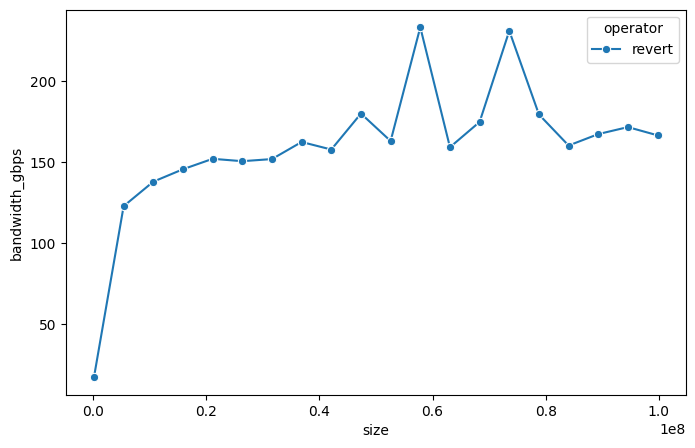

In [11]:
plt.figure(figsize=(8, 5))
sns.lineplot(x='size', y='bandwidth_gbps', hue='operator', data=revert_df, marker='o')
